In [2]:
!pip install pandas numpy
!pip install nltk
!pip install plotly
!pip install wordcloud
!pip install -U sentence-transformers
!pip install contractions
!pip install scikit-learn

In [9]:
!pip install contractions
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# 1- Import data from a website using the requests library and format it as a reusable DataFrame.

In [5]:
import requests
import pandas as pd

def extract_all_data():
    x = ["1000", "2000", "3000", "4000", "5500"]
    data = ""
    for x_i in x:
        data += requests.get(f'https://cogcomp.seas.upenn.edu/Data/QA/QC/train_{x_i}.label').text
        data += "\n"
    data_list = data.split("\n")
    data_json = {
        "target": [],
        "question": []
    }
    for d in data_list:
        try:
            if len(d) > 0:
                index = d.index(':')
                main_category = d[:index]
                subtype, question = d[index+1:].split(" ", 1)  # Extract subtype and question
                data_json["target"].append(main_category+" "+subtype)
                data_json["question"].append(question)
        except Exception as e:
            print(f"Error processing line: {d} -> {e}")
    return data_json

# Convert extracted data into a DataFrame
train_data = pd.DataFrame(extract_all_data())
train_data.head()

,target,question
0,DESC manner,How did serfdom develop in and then leave Russ...
1,ENTY cremat,What films featured the character Popeye Doyle ?
2,DESC manner,How can I find a list of celebrities ' real na...
3,ENTY animal,What fowl grabs the spotlight after the Chines...
4,ABBR exp,What is the full form of .com ?


# Exploration

In [6]:
train_data.head()


,target,question
0,DESC manner,How did serfdom develop in and then leave Russ...
1,ENTY cremat,What films featured the character Popeye Doyle ?
2,DESC manner,How can I find a list of celebrities ' real na...
3,ENTY animal,What fowl grabs the spotlight after the Chines...
4,ABBR exp,What is the full form of .com ?


In [7]:
classes_names= train_data["target"].unique()
classes_names


array(['DESC manner', 'ENTY cremat', 'ENTY animal', 'ABBR exp', 'HUM ind',
       'HUM gr', 'HUM title', 'DESC def', 'NUM date', 'DESC reason',
       'ENTY event', 'LOC state', 'DESC desc', 'NUM count', 'ENTY other',
       'ENTY letter', 'LOC other', 'ENTY religion', 'ENTY food',
       'LOC country', 'ENTY color', 'ENTY termeq', 'LOC city',
       'ENTY body', 'ENTY dismed', 'LOC mount', 'NUM money',
       'ENTY product', 'NUM period', 'ENTY substance', 'ENTY sport',
       'ENTY plant', 'ENTY techmeth', 'NUM volsize', 'HUM desc',
       'ENTY instru', 'ABBR abb', 'NUM other', 'NUM speed', 'ENTY word',
       'ENTY lang', 'NUM perc', 'NUM code', 'NUM dist', 'NUM temp',
       'ENTY symbol', 'NUM ord', 'ENTY veh', 'NUM weight',
       'ENTY currency'], dtype=object)

# 2 -Data Preprocessing

In [10]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from nltk.stem import WordNetLemmatizer
import re
import string
import inflect
import contractions
p_inf = inflect.engine()
tokens = word_tokenize(" Hello word i am his bitch ")
stop_words = set(stopwords.words('english'))
p = PorterStemmer()
def convert_number(text):
    tokens = word_tokenize(text)
    for i in range(len(tokens)):
        if(tokens[i].isdigit()):
            tokens[i] = p_inf.number_to_words(tokens[i])
    return " ".join(tokens)
def remove_punctuation(text):
    translator= str.maketrans('','',string.punctuation)
    return text.translate(translator)
# methode to clean text

def preprocess_text (text):

    """
    Clean, tokenize, and stem the input text.

    Steps:
    - Convert to lowercase
    - Remove extra whitespace
    - Convert numbers to words
    - Remove punctuation
    - Remove stopwords
    - Apply stemming
    """
    #Text Lowercase
    text = text.lower()
    ##don't to do not
    text = contractions.fix(text)
    ## special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # remove whitespace from text
    text = " ".join(text.split())
    # convert numbers to text
    text = convert_number(text)
    # remove punctuation
    text = remove_punctuation(text)
    # Apply stemming
    text= " ".join( [w for w in word_tokenize(text) if w not in stop_words ])
    return  " ".join([ p.stem(w) for w in word_tokenize(text) ] )

input_text = "Hello world! I am excited to learn text preprocessing."
cleaned_text = preprocess_text(input_text)
print(cleaned_text)



hello world excit learn text preprocess


In [11]:

questions = train_data.question.str.cat(sep = ' ')
tokens = word_tokenize(preprocess_text(questions))
tokens = [w for w in tokens ]
vocabulary = set(tokens)
frequency_dist = nltk.FreqDist(tokens)
#sorted(frequency_dist,key=frequency_dist.__getitem__, reverse=True)[0:50]

# 3 - Data Visulizations

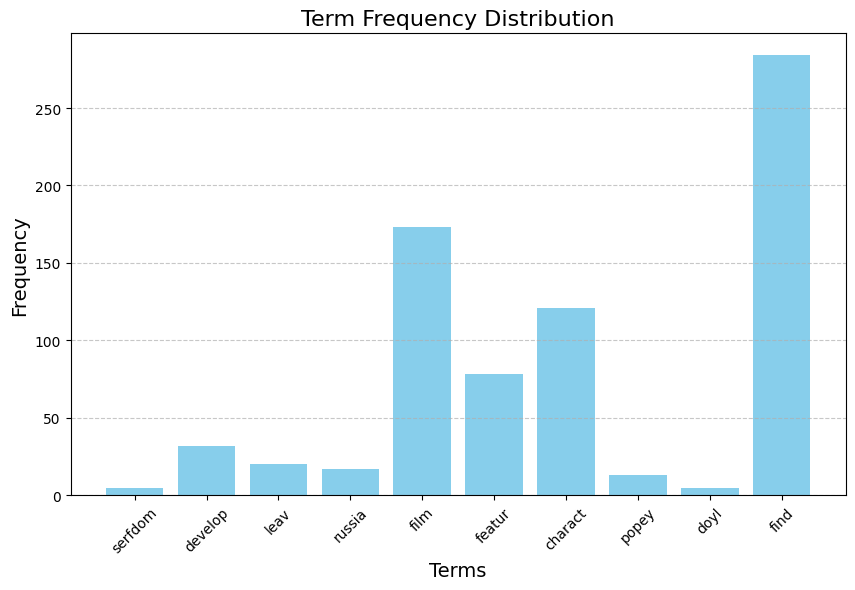

In [12]:
import matplotlib.pyplot as plt

terms = list(frequency_dist.keys())[0:10]
frequencies = list(frequency_dist.values())[0:10]

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(terms, frequencies, color='skyblue')
plt.xlabel("Terms", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Term Frequency Distribution", fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

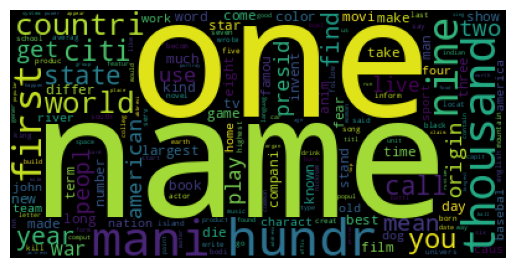

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
wordcloud = WordCloud().generate_from_frequencies(frequency_dist)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# 4 - Transform Data into usefull Representation


In [36]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()
X,y = train_data.question,label_encoder.fit_transform(train_data.target)
(X_train, X_test, y_train, y_test) = train_test_split(X, y,test_size = .2,random_state = 22)


In [37]:
def get_corpus(X):
     corpus = list(X)
     vocabulary = set(corpus)

     new_corpus = []
     for c in corpus :
        new_corpus.append(preprocess_text(c))
     return new_corpus
corpus_train=get_corpus(X_train)
corpus_test = get_corpus(X_test)


In [38]:
#from sklearn.feature_extraction.text import TfidfTransformer
#from sklearn.feature_extraction.text import TfidfVectorizer
model = SentenceTransformer("all-MiniLM-L6-v2")

#vectorizer = TfidfVectorizer()
#train_vectors = vectorizer.fit_transform(X_train)
#test_vectors = vectorizer.transform(X_test)
train_model_data = model.encode(corpus_train)
test_model_data = model.encode(corpus_test)
print(train_model_data.shape, test_model_data.shape)

(12361, 384) (3091, 384)


In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [40]:
train_model_data = torch.tensor(train_model_data,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.long)
y_test = torch.tensor(y_test,dtype=torch.long)

test_model_data = torch.tensor(test_model_data,dtype=torch.float32)


In [21]:
import torch
import torch.nn as nn

class QuestionClassificationModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0):
        super(QuestionClassificationModel, self).__init__()

        # LSTM Layer
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        # Fully Connected Layer
        self.fc = nn.Linear(hidden_size * 2, output_size)  # *2 for bidirectional LSTM

    def forward(self, x):
        # LSTM Forward Pass
        lstm_out, _ = self.lstm(x)

        # Use the last hidden state for classification
        out = self.fc(lstm_out[:, -1, :])  # Last hidden state

        return out

# Hyperparameters
input_size = train_model_data.shape[1]  # Embedding size
hidden_size = 128  # Number of features in hidden state
output_size = len(label_encoder.classes_)  # Number of classes
num_layers =  2 # Stack 2 LSTM layers
dropout = 0  # Dropout for regularization
learning_rate = 0.001
num_epochs = 50

# Initialize model, loss, and optimizer
model_lstm = QuestionClassificationModel(input_size, hidden_size, output_size, num_layers, dropout)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=learning_rate)

# Convert data to appropriate shape
train_model_data = train_model_data.unsqueeze(1)  # Add sequence length dimension
test_model_data = test_model_data.unsqueeze(1)

# Train the LSTM model
for epoch in range(num_epochs):
    # Forward pass
    outputs = model_lstm(train_model_data)
    loss = criterion(outputs, y_train.long())  # Ensure y_train is of type Long

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluate the model
with torch.no_grad():
    y_pred = model_lstm(test_model_data)
    y_pred_classes = torch.argmax(y_pred, dim=1)
    accuracy = (y_pred_classes == y_test).float().mean()
    print(f"Test Accuracy: {accuracy:.4f}")


Epoch [1/50], Loss: 3.9202
Epoch [2/50], Loss: 3.9125
Epoch [3/50], Loss: 3.9050
Epoch [4/50], Loss: 3.8973
Epoch [5/50], Loss: 3.8895
Epoch [6/50], Loss: 3.8812
Epoch [7/50], Loss: 3.8723
Epoch [8/50], Loss: 3.8625
Epoch [9/50], Loss: 3.8518
Epoch [10/50], Loss: 3.8398
Epoch [11/50], Loss: 3.8263
Epoch [12/50], Loss: 3.8110
Epoch [13/50], Loss: 3.7938
Epoch [14/50], Loss: 3.7743
Epoch [15/50], Loss: 3.7523
Epoch [16/50], Loss: 3.7274
Epoch [17/50], Loss: 3.6996
Epoch [18/50], Loss: 3.6686
Epoch [19/50], Loss: 3.6344
Epoch [20/50], Loss: 3.5971
Epoch [21/50], Loss: 3.5569
Epoch [22/50], Loss: 3.5144
Epoch [23/50], Loss: 3.4703
Epoch [24/50], Loss: 3.4259
Epoch [25/50], Loss: 3.3825
Epoch [26/50], Loss: 3.3420
Epoch [27/50], Loss: 3.3060
Epoch [28/50], Loss: 3.2760
Epoch [29/50], Loss: 3.2529
Epoch [30/50], Loss: 3.2370
Epoch [31/50], Loss: 3.2278
Epoch [32/50], Loss: 3.2243
Epoch [33/50], Loss: 3.2244
Epoch [34/50], Loss: 3.2259
Epoch [35/50], Loss: 3.2261
Epoch [36/50], Loss: 3.2230
E

In [28]:
import torch
import torch.nn as nn

class QuestionClassificationModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.3):
        super(QuestionClassificationModel, self).__init__()

        # Fully connected layers
        self.lin1 = nn.Linear(input_size, hidden_size)  # input_size should be 384 based on your input data
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.lin2 = nn.Linear(hidden_size, output_size)  # output_size is number of classes
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.lin1(x)
        x = self.relu(x)
        x = self.dropout(x)  # Apply dropout
        x = self.lin2(x)
        x = self.softmax(x)  # Softmax for multi-class classification
        return x

# Hyperparameters
input_size = train_model_data.shape[1]  # Embedding size (should be 384 for "all-MiniLM-L6-v2" model)
hidden_size = 128  # Number of features in hidden state
output_size = len(label_encoder.classes_)  # Number of classes (the number of question types)
dropout = 0.3  # Dropout for regularization
learning_rate = 0.001
num_epochs = 50



# Initialize model, loss, and optimizer
model = QuestionClassificationModel(input_size, hidden_size, output_size, dropout)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    # Forward pass
    outputs = model(train_model_data)  # No need for unsqueeze
    loss = criterion(outputs, y_train)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluate the model
model.eval()  # Set model to evaluation mode
with torch.no_grad():
    y_pred = model(test_model_data)  # No need for unsqueeze
    y_pred_classes = torch.argmax(y_pred, dim=1)
    accuracy = (y_pred_classes == y_test).float().mean()
    print(f"Test Accuracy: {accuracy:.4f}")


Epoch [1/50], Loss: 3.9122
Epoch [2/50], Loss: 3.9120
Epoch [3/50], Loss: 3.9119
Epoch [4/50], Loss: 3.9117
Epoch [5/50], Loss: 3.9115
Epoch [6/50], Loss: 3.9114
Epoch [7/50], Loss: 3.9112
Epoch [8/50], Loss: 3.9110
Epoch [9/50], Loss: 3.9107
Epoch [10/50], Loss: 3.9105
Epoch [11/50], Loss: 3.9102
Epoch [12/50], Loss: 3.9099
Epoch [13/50], Loss: 3.9096
Epoch [14/50], Loss: 3.9093
Epoch [15/50], Loss: 3.9089
Epoch [16/50], Loss: 3.9084
Epoch [17/50], Loss: 3.9080
Epoch [18/50], Loss: 3.9074
Epoch [19/50], Loss: 3.9069
Epoch [20/50], Loss: 3.9063
Epoch [21/50], Loss: 3.9056
Epoch [22/50], Loss: 3.9048
Epoch [23/50], Loss: 3.9041
Epoch [24/50], Loss: 3.9032
Epoch [25/50], Loss: 3.9022
Epoch [26/50], Loss: 3.9012
Epoch [27/50], Loss: 3.9001
Epoch [28/50], Loss: 3.8989
Epoch [29/50], Loss: 3.8976
Epoch [30/50], Loss: 3.8962
Epoch [31/50], Loss: 3.8947
Epoch [32/50], Loss: 3.8932
Epoch [33/50], Loss: 3.8914
Epoch [34/50], Loss: 3.8897
Epoch [35/50], Loss: 3.8879
Epoch [36/50], Loss: 3.8859
E

In [41]:
import torch
import torch.nn as nn

class QuestionClassificationModelGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0):
        super(QuestionClassificationModelGRU, self).__init__()

        # GRU Layer
        self.gru = nn.GRU(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True  # Bidirectional GRU
        )

        # Fully Connected Layer
        self.fc = nn.Linear(hidden_size * 2, output_size)  # *2 for bidirectional GRU

    def forward(self, x):
        # GRU Forward Pass
        gru_out, _ = self.gru(x)

        # Use the last hidden state for classification
        out = self.fc(gru_out[:, -1, :])  # Last hidden state

        return out

# Hyperparameters
input_size = 384  # Size of the embeddings from SentenceTransformer
hidden_size = 128  # Number of features in hidden state
output_size = len(label_encoder.classes_)  # Number of classes
num_layers = 3
dropout = 0  # Dropout for regularization
learning_rate = 0.001
num_epochs = 50

# Initialize model, loss, and optimizer
model_gru = QuestionClassificationModelGRU(input_size, hidden_size, output_size, num_layers, dropout)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_gru.parameters(), lr=learning_rate)

# Convert data to appropriate shape
train_model_data = torch.tensor(train_model_data, dtype=torch.float32).unsqueeze(1)  # Add sequence length dimension (batch, seq_len, input_size)
test_model_data = torch.tensor(test_model_data, dtype=torch.float32).unsqueeze(1)   # Add sequence length dimension

# Train the GRU model
for epoch in range(num_epochs):
    # Forward pass
    outputs = model_gru(train_model_data)
    loss = criterion(outputs, y_train.long())  # Ensure y_train is of type Long

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluate the model
with torch.no_grad():
    y_pred = model_gru(test_model_data)
    y_pred_classes = torch.argmax(y_pred, dim=1)
    accuracy = (y_pred_classes == y_test).float().mean()
    print(f"Test Accuracy: {accuracy:.4f}")

<ipython-input-41-282f462cac9b>:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_model_data = torch.tensor(train_model_data, dtype=torch.float32).unsqueeze(1)  # Add sequence length dimension (batch, seq_len, input_size)
<ipython-input-41-282f462cac9b>:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_model_data = torch.tensor(test_model_data, dtype=torch.float32).unsqueeze(1)   # Add sequence length dimension


Epoch [1/50], Loss: 3.9112
Epoch [2/50], Loss: 3.8933
Epoch [3/50], Loss: 3.8754
Epoch [4/50], Loss: 3.8562
Epoch [5/50], Loss: 3.8346
Epoch [6/50], Loss: 3.8096
Epoch [7/50], Loss: 3.7798
Epoch [8/50], Loss: 3.7439
Epoch [9/50], Loss: 3.7005
Epoch [10/50], Loss: 3.6481
Epoch [11/50], Loss: 3.5859
Epoch [12/50], Loss: 3.5143
Epoch [13/50], Loss: 3.4358
Epoch [14/50], Loss: 3.3562
Epoch [15/50], Loss: 3.2861
Epoch [16/50], Loss: 3.2400
Epoch [17/50], Loss: 3.2288
Epoch [18/50], Loss: 3.2468
Epoch [19/50], Loss: 3.2678
Epoch [20/50], Loss: 3.2729
Epoch [21/50], Loss: 3.2611
Epoch [22/50], Loss: 3.2392
Epoch [23/50], Loss: 3.2145
Epoch [24/50], Loss: 3.1929
Epoch [25/50], Loss: 3.1772
Epoch [26/50], Loss: 3.1680
Epoch [27/50], Loss: 3.1638
Epoch [28/50], Loss: 3.1629
Epoch [29/50], Loss: 3.1631
Epoch [30/50], Loss: 3.1628
Epoch [31/50], Loss: 3.1608
Epoch [32/50], Loss: 3.1569
Epoch [33/50], Loss: 3.1512
Epoch [34/50], Loss: 3.1443
Epoch [35/50], Loss: 3.1372
Epoch [36/50], Loss: 3.1304
E

# Evaluate the model test data

In [42]:
import requests
import pandas as pd
def extract_test_data():

    data= ""
    for x_i in x:
        data += requests.get("https://cogcomp.seas.upenn.edu/Data/QA/QC/TREC_10.label").text
        data += "\n"
    data_list=data.split("\n")
    data_json = {
        "target" : [],
        "question" : []
    }
    for d in data_list :
        try:
          if(len(d) > 0) :
            index = d.index(':') #The index() method in Python is used to find the first occurrence of a specified value within a string
            label, question = d[:index],d[index+1:]
            data_json["target"].append(label)
            data_json["question"].append(question)
        except:
            print(d)
    return data_json


test_evaluation_data=pd.DataFrame(extract_all_data())

In [43]:
X_test,y_test = test_evaluation_data.question,label_encoder.fit_transform(test_evaluation_data.target)
corpus_test = get_corpus(X_test)
test_model_data = model.encode(corpus_test)
y_test = torch.tensor(y_test,dtype=torch.long)
test_model_evaluation = torch.tensor(test_model_data,dtype=torch.float32).unsqueeze(1)
model_gru.eval()

with torch.no_grad():
    y_pred = model_gru(test_model_evaluation)
    y_pred_classes = torch.argmax(y_pred, dim=1)
    accuracy = (y_pred_classes == y_test).float().mean()
    print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.1885


In [44]:
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score

y_pred_classes_np = y_pred_classes.cpu().numpy()
y_test_np = y_test.cpu().numpy()

    # F1 Score
f1 = f1_score(y_test_np, y_pred_classes_np, average='weighted')
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.0756


In [45]:
 # Precision
precision = precision_score(y_test_np, y_pred_classes_np, average='weighted')
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test_np, y_pred_classes_np, average='weighted')
print(f"Recall: {recall:.4f}")

Precision: 0.1246
Recall: 0.1885


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


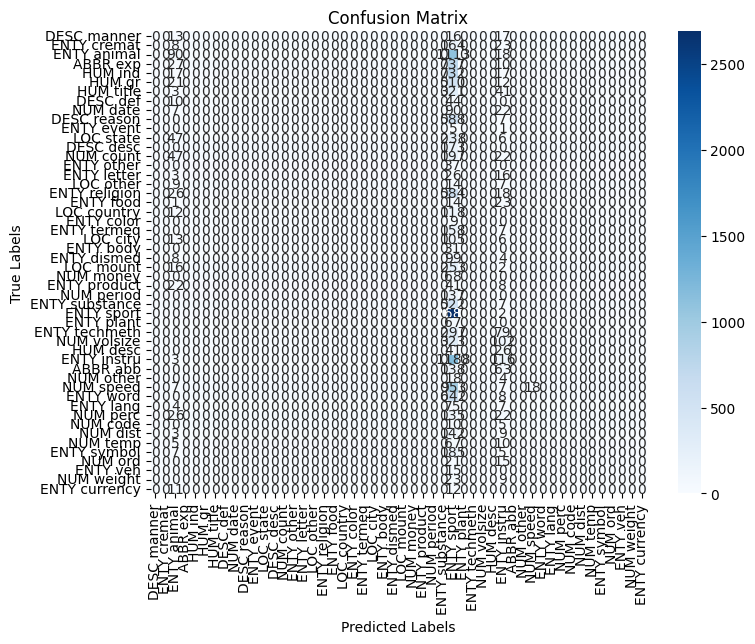

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test_np, y_pred_classes_np)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
